<a href="https://colab.research.google.com/github/Paevjc/Sales-Analysis/blob/main/Group2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd # analyze data
import numpy as np # work with arrays
import scipy.stats as stats # for statistical procedures such as t-test etc.
import seaborn as sns # data visualisation library
import matplotlib.pyplot as plt

#libraries used for handling missing and non-numeric values - part of data cleaning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler

#Pipeline : Chains all steps of the workflow for a more streamlined procedure.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


#Feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression,chi2

#Training data
from sklearn.model_selection import train_test_split #Split arrays or matrices into random train and test subsets.
from sklearn.model_selection import cross_val_score # Evaluate a score by cross-validation.
from sklearn.model_selection import StratifiedShuffleSplit #Random permutation cross-validator
from sklearn.model_selection import GridSearchCV # Exhaustive search over specified parameter values for an estimator

#linear regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso

#Decision tree Regressor
from sklearn.tree import DecisionTreeRegressor


#KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# Gaussian Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB

# Logistic Regression
from sklearn.linear_model import LogisticRegression

#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

#SVM
from sklearn.svm import SVC

#R2 square and mean squared error
from sklearn import metrics
from sklearn.metrics import r2_score,mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
retail_df = pd.read_csv('/content/drive/My Drive/DAC/Copy of retail.csv', encoding='ISO-8859-1')
retaildesc_df = pd.read_csv('/content/drive/My Drive/DAC/Copy of retail_description.csv')

In [ ]:
df = retail_df.copy(deep=True)

# Displays all columns of the dataset
pd.set_option('display.max_columns', None)

In [ ]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

Logistic Insights
* Yin Wei

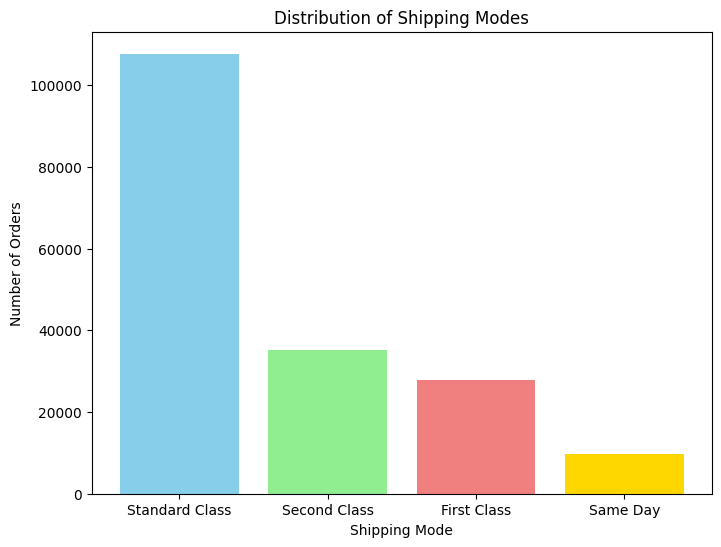

In [ ]:
shipping_mode_counts = df['Shipping Mode'].value_counts()
total_orders = len(df)

plt.figure(figsize=(8, 6))
plt.bar(shipping_mode_counts.index, shipping_mode_counts, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])

plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.title('Distribution of Shipping Modes')

plt.show()

Market Performance
- Jade

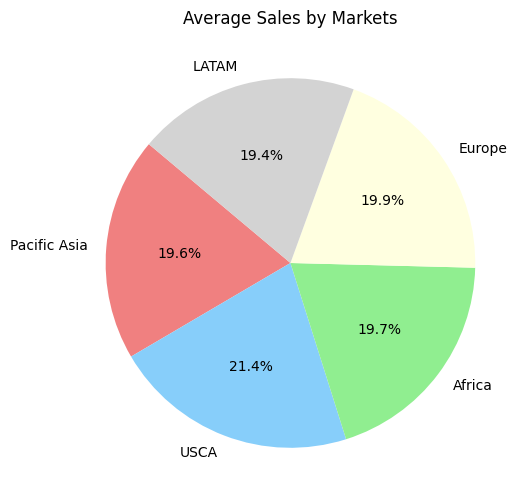

In [ ]:
market = df['Market'].unique()
average_sales = df.groupby('Market')['Sales'].mean()
colors = ['lightcoral', 'lightskyblue', 'lightgreen', 'lightyellow', 'lightgrey']

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(average_sales, labels=market, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Average Sales by Markets')

plt.show()

Distribution of Product and Shipping Mode
* Yin Wei

<Figure size 1400x800 with 0 Axes>

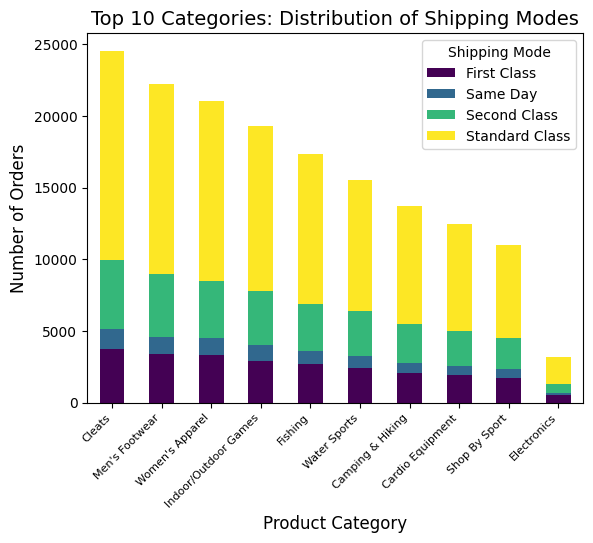

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped_counts = df.groupby(['Category Name', 'Shipping Mode']).size().unstack(fill_value=0)

total_orders_per_category = grouped_counts.sum(axis=1)
top_10_categories = total_orders_per_category.sort_values(ascending=False).head(10).index

grouped_counts_top_10 = grouped_counts.loc[top_10_categories]

plt.figure(figsize=(14, 8))
ax = grouped_counts_top_10.plot(kind='bar', stacked=True, colormap='viridis')

plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Top 10 Categories: Distribution of Shipping Modes', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(title='Shipping Mode', bbox_to_anchor=(1, 1), fontsize=10)
plt.show()


Benefit per orderacross different product categories
* Yin Wei

<ipython-input-11-44d28be12677>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Benefit per order', y='Category Name', data=df, ci=None, palette='viridis')


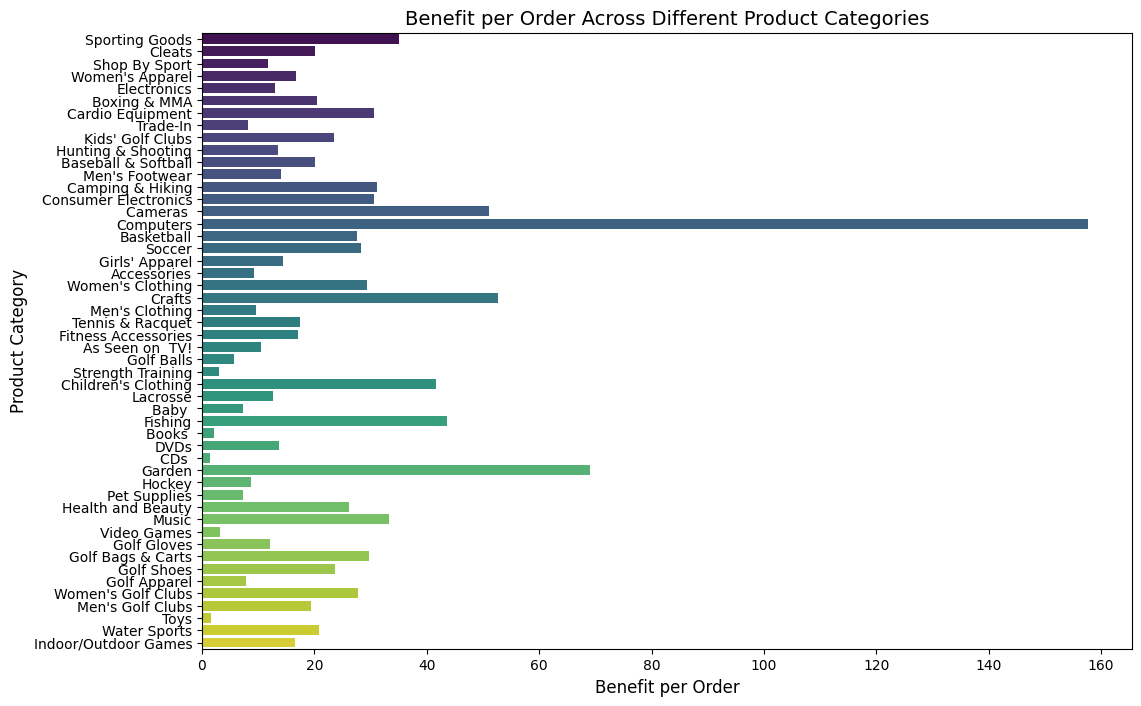

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Benefit per order', y='Category Name', data=df, ci=None, palette='viridis')

# Add labels and title
plt.xlabel('Benefit per Order', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.title('Benefit per Order Across Different Product Categories', fontsize=14)

# Display the bar chart without error bars
plt.show()


Market Sales across the Years
- Jade

In [ ]:
subset = df[['order date (DateOrders)', 'Sales per customer']]

# Assuming 'df' is your DataFrame with a 'order date (DateOrders)' column
subset['order date'] = pd.to_datetime(subset['order date (DateOrders)'], format='%m/%d/%Y %H:%M')

# Extract the year into a new column
subset['order month'] = subset['order date'].dt.strftime('%Y-%m')

subset.head(20)

<ipython-input-13-0052f4615eae>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['order date'] = pd.to_datetime(subset['order date (DateOrders)'], format='%m/%d/%Y %H:%M')
<ipython-input-13-0052f4615eae>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['order month'] = subset['order date'].dt.strftime('%Y-%m')


,order date (DateOrders),Sales per customer,order date,order month
0,1/31/2018 22:56,314.640015,2018-01-31 22:56:00,2018-01
1,1/13/2018 12:27,311.359985,2018-01-13 12:27:00,2018-01
2,1/13/2018 12:06,309.720001,2018-01-13 12:06:00,2018-01
3,1/13/2018 11:45,304.809998,2018-01-13 11:45:00,2018-01
4,1/13/2018 11:24,298.250000,2018-01-13 11:24:00,2018-01
5,1/13/2018 11:03,294.980011,2018-01-13 11:03:00,2018-01
6,1/13/2018 10:42,288.420013,2018-01-13 10:42:00,2018-01
7,1/13/2018 10:21,285.140015,2018-01-13 10:21:00,2018-01
8,1/13/2018 10:00,278.589996,2018-01-13 10:00:00,2018-01
9,1/13/2018 9:39,275.309998,2018-01-13 09:39:00,2018-01


In [ ]:
# Group by month and sum the sales
monthly_sales = subset.groupby('order month')['Sales per customer'].sum().reset_index()
monthly_sales.head()

,order month,Sales per customer
0,2015-01,945382.160534
1,2015-02,833012.429253
2,2015-03,944050.110472
3,2015-04,912004.400261
4,2015-05,943939.769956


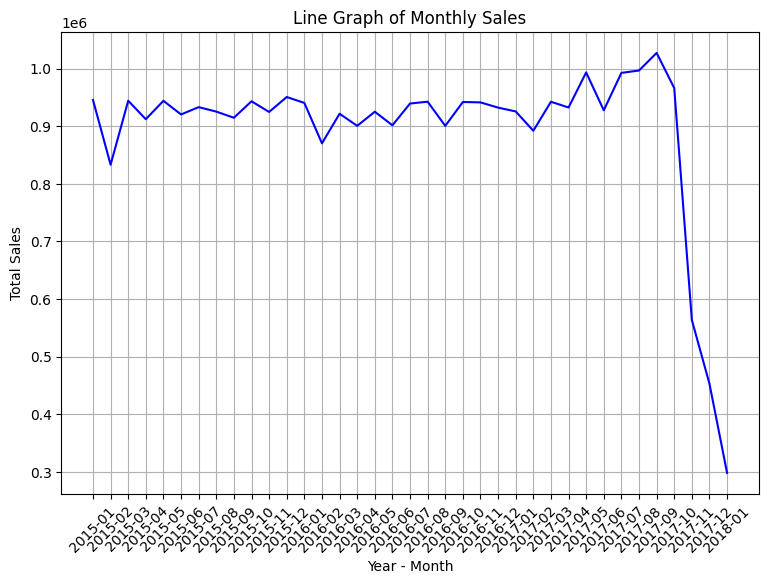

In [ ]:
# Plotting a line graph
plt.figure(figsize=(9, 6))
plt.plot(monthly_sales['order month'], monthly_sales['Sales per customer'], color='blue')
plt.title('Line Graph of Monthly Sales')
plt.xlabel('Year - Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)
plt.show()

# Data Cleaning

- Luqman

In [ ]:
#check for null-values
df.isna().sum()
#`Order Zipcode` and `Product Description` are the only variables with - however we aren't using them so we don't remove just yet.

#check for duplicates
df[df.duplicated()]
#No duplicates

#drop irrelevant columns
df_new = df[["Sales", "Sales per customer", "Order Item Quantity", "Order Item Product Price",
             "Order Item Profit Ratio", "Order Region", "Category Name", "Product Price",
             "Order Profit Per Order", "Order Item Discount"]] # > we looked at correlation
# df_new.info()

#use Pipeline to convert categorical variables to numerical ones and scale
numeric_cols = list(df_new.select_dtypes(['float64','int64']).columns)
categorical_cols = ['Order Region', 'Category Name']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('std_scaler', StandardScaler())
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat',OrdinalEncoder(),categorical_cols)
])

features = full_pipeline.fit_transform(df_new)
features = pd.DataFrame(data = features, columns = numeric_cols + categorical_cols)
target = df_new['Sales']
features = features.drop(columns = ['Sales'])
features.head()


,Sales per customer,Order Item Quantity,Order Item Product Price,Order Item Profit Ratio,Product Price,Order Profit Per Order,Order Item Discount,Order Region,Category Name
0,1.095708,-0.775836,1.334822,0.362801,1.334822,0.663343,-0.346534,15.0,40.0
1,1.068384,-0.775836,1.334822,-1.972275,1.334822,-2.595582,-0.196082,13.0,40.0
2,1.054722,-0.775836,1.334822,-1.972275,1.334822,-2.583038,-0.120855,13.0,40.0
3,1.013820,-0.775836,1.334822,-0.087076,1.334822,0.008474,0.104366,11.0,40.0
4,0.959174,-0.775836,1.334822,0.705564,1.334822,1.074706,0.405271,11.0,40.0


# Machine Learning

Train & Test Dataset
* Luqman

In [ ]:
selected_features = []

selector = SelectKBest(f_regression, k = 'all')
selector.fit_transform(features, target)

supports = selector.get_support()

print(supports)
print(features.columns)

[ True  True  True  True  True  True  True  True  True]
Index(['Sales per customer', 'Order Item Quantity', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Product Price', 'Order Profit Per Order',
       'Order Item Discount', 'Order Region', 'Category Name'],
      dtype='object')


In [ ]:
for support, feature in zip(supports, features.columns):

  if (support == True):
    selected_features.append(feature)

print('Selected features are: ', selected_features)

Selected features are:  ['Sales per customer', 'Order Item Quantity', 'Order Item Product Price', 'Order Item Profit Ratio', 'Product Price', 'Order Profit Per Order', 'Order Item Discount', 'Order Region', 'Category Name']


In [ ]:
# splitting the dataset
X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=21)

Scatterplot

- Luqman

Mean Squared Error; 2.3154491256341288e-06
R-squared: 0.9999999998665815


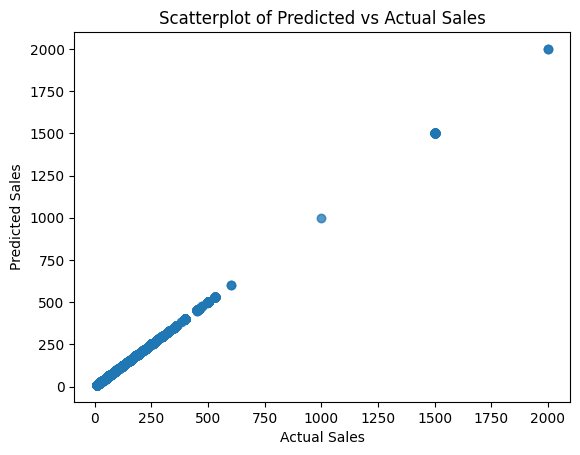

In [ ]:
# Instantiate and train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# make predictions on the test set
y_pred = model.predict(X_test)

# Compute R-squared value
r_squared = r2_score(y_test, y_pred)

# Evaluate the model's performance
mse= mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error; {mse}')
print(f'R-squared: {r_squared}')

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Scatterplot of Predicted vs Actual Sales")
plt.show()

Variance Inflation Factor (VIF)

- Luqman

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
  vif = pd.DataFrame()
  vif["features"] = X.columns
  vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

  return(vif)

X = features
calc_vif(X)

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


,features,VIF
0,Sales per customer,12.030608
1,Order Item Quantity,6.607412
2,Order Item Product Price,inf
3,Order Item Profit Ratio,3.237290
4,Product Price,inf
5,Order Profit Per Order,3.296001
6,Order Item Discount,1.683199
7,Order Region,2.538609
8,Category Name,2.627952


Hypothesis Testing
- Jade

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Assuming X_train, y_train are your training features and target
# X_test, y_test are your testing features and target

# Fit a linear regression model
model = sm.OLS(y_train, sm.add_constant(X_train))
results = model.fit()

# Display the summary statistics
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.370e+14
Date:                Fri, 15 Dec 2023   Prob (F-statistic):               0.00
Time:                        17:15:00   Log-Likelihood:             7.3220e+05
No. Observations:              144415   AIC:                        -1.464e+06
Df Residuals:                  144406   BIC:                        -1.464e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

Checking VIF again
- Jade

In [ ]:
X = features.drop(['Order Item Profit Ratio','Order Profit Per Order', 'Order Region','Order Item Product Price'],axis=1)
calc_vif(X)

,features,VIF
0,Sales per customer,11.702088
1,Order Item Quantity,6.547268
2,Product Price,17.231019
3,Order Item Discount,1.674327
4,Category Name,1.035500


Pearson Correlation
- Jade

In [ ]:
# Assuming df is your DataFrame
correlation_matrix = df_new[['Sales per customer', 'Product Price']].corr()

# Extract the Pearson correlation coefficient
correlation_coefficient = correlation_matrix.loc['Sales per customer', 'Product Price']

print(f"Pearson correlation coefficient: {correlation_coefficient}")

Pearson correlation coefficient: 0.7817814277172019


Interaction Term
- Jade

In [ ]:
# Create Interaction Term
df['InteractionTerm'] = df['Sales per customer'] * df['Product Price']

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,InteractionTerm
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,103123.264785
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class,102048.235215
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class,101510.730393
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,99901.476713
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,97751.437500


In [ ]:
df_revised = df[["Sales", "Order Item Quantity", "Order Item Discount", "Category Name", "InteractionTerm"]]

# use Pipeline to convert categorical variables to numerical ones and scale
numeric_cols = list(df_revised.select_dtypes(['float64','int64']).columns)
categorical_cols = ['Category Name']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('std_scaler', StandardScaler())
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat',OrdinalEncoder(),categorical_cols)
])

features = full_pipeline.fit_transform(df_revised)
revised_features = pd.DataFrame(data = features, columns = numeric_cols + categorical_cols)
target = df_revised['Sales']
revised_features = revised_features.drop(columns = ['Sales'])

selected_features = []

selector = SelectKBest(f_regression, k = 'all')
selector.fit_transform(revised_features, target)

supports = selector.get_support()

for support, feature in zip(supports, revised_features.columns):

  if (support == True):
    selected_features.append(feature)

X_train,X_test,y_train,y_test = train_test_split(revised_features,target,test_size=0.2,random_state=21)

In [ ]:
revised_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order Item Quantity  180519 non-null  float64
 1   Order Item Discount  180519 non-null  float64
 2   InteractionTerm      180519 non-null  float64
 3   Category Name        180519 non-null  float64
dtypes: float64(4)
memory usage: 5.5 MB


In [ ]:
def calc_vif(X):
  vif = pd.DataFrame()
  vif["revised_features"] = X.columns
  vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

  return(vif)

X = revised_features
calc_vif(X)

,revised_features,VIF
0,Order Item Quantity,1.060556
1,Order Item Discount,1.246565
2,InteractionTerm,1.279176
3,Category Name,1.012698


Revised Linear Regression Model
- Jade

In [ ]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_linreg = linreg.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_linreg)
rmse_lr = np.sqrt(mse_lr)
r2_score_lr = r2_score(y_test, y_pred_linreg)
print('The root mean squared error is : ', rmse_lr)
print('The r2_score is : ', r2_score_lr)

The root mean squared error is :  69.20375721433847
The r2_score is :  0.7240438064123428


Actual Vs predicted value (residual plot)

- Yin Wei

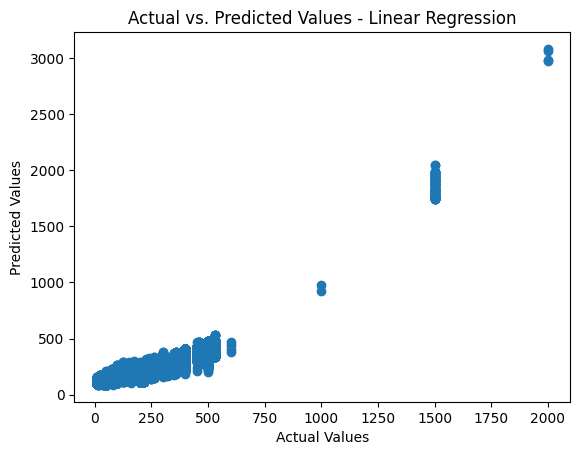

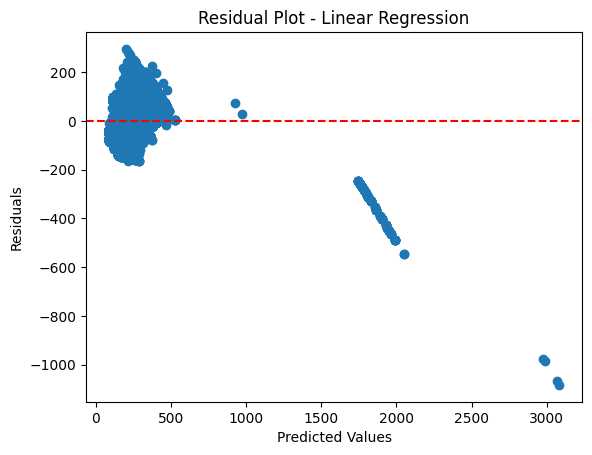

In [ ]:
plt.scatter(y_test, y_pred_linreg)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values - Linear Regression')
plt.show()

# Residual Analysis
residuals_lr = y_test - y_pred_linreg
plt.scatter(y_pred_linreg, residuals_lr)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

**Classification Techniques**

We want to let our categorical variable `Category Name` be the target. And the rest of our variables be our features. We then classify `Category Name` by the following ML models.

- Luqman

In [ ]:
numeric_cols = list(df_revised.select_dtypes(['float64','int64']).columns)
categorical_cols = ['Category Name']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('std_scaler', StandardScaler())
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat',OrdinalEncoder(),categorical_cols)
])

features = full_pipeline.fit_transform(df_revised)
revised_features = pd.DataFrame(data = features, columns = numeric_cols + categorical_cols)
target = df_revised['Category Name']
revised_features = revised_features.drop(columns = ['Category Name'])


X_train,X_test,y_train,y_test = train_test_split(revised_features,target,test_size=0.2,random_state=21)

K-Nearest Neighbours Classifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5) #by default is 5 neighbors

knn.fit(X_train, y_train)

Y_pred = knn.predict(X_test)

# Accuracy is calculated by comparing whether our predicted category (Y_pred) is align with what the correct/original category (Y_test).

accuracy_knn = round(metrics.accuracy_score(y_test, Y_pred)*100, 2)
print("Accuracy of KNN is", accuracy_knn)

Accuracy of KNN is 96.69


Logistic Regression

In [ ]:
LR = LogisticRegression()

LR.fit(X_train, y_train)

Y_pred = LR.predict(X_test)

accuracy_LR = round(metrics.accuracy_score(y_test, Y_pred)*100, 2)
print("Accuracy of Logistic Regression is", accuracy_LR)

Accuracy of Logistic Regression is 73.3


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

Y_pred = dtc.predict(X_test)

accuracy_dtc = round(metrics.accuracy_score(y_test, Y_pred)*100, 2)
print("Accuracy of Decision Tree Classifier is", accuracy_dtc)

Accuracy of Decision Tree Classifier is 97.62


In [ ]:
svc = SVC()

svc.fit(X_train, y_train)

Y_pred = svc.predict(X_test)

accuracy_svc = round(metrics.accuracy_score(y_test, Y_pred)*100, 2)
print("Accuracy of SVM is", accuracy_svc)

KeyboardInterrupt: ignored

In [ ]:
gaussian = GaussianNB()

gaussian.fit(X_train, y_train)

Y_pred = gaussian.predict(X_test)

accuracy_gnb = round(metrics.accuracy_score(y_test, Y_pred)*100, 2)
print("Accuracy of Gaussian Naive Bayes is", accuracy_gnb)

In [ ]:
models = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'Logistic Regression',
              'Decision Tree Classifier','Support Vector Machines'],
    'Score': [accuracy_knn, accuracy_gnb, accuracy_LR,
              accuracy_dtc, accuracy_svc]})
models.sort_values(by='Score', ascending=False)